# STATISTICS

In [72]:
# import libraries
import os
import glob
import pandas as pd
import numpy as np
import math
import scipy
import matplotlib.pyplot as plt
import math
import xml.etree.ElementTree as ET
import seaborn as sns
import seaborn.objects as so
from sklearn.preprocessing import StandardScaler
import umap

curfolder = os.getcwd()
print(curfolder)

flesh_folder = os.path.dirname(curfolder)
features = flesh_folder + '/Feature_Extraction_folder/feature_extraction_with2d_february.csv'

features = pd.read_csv(features)

features



/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/StatisticsFolder


,participantID,Age,BirthPlace,Gender,NativeLanguages,NumOfNativeLanguages,Other Languages,TotalLanguages,Extroversion,Hand,...,right_wrist_AccelAVG,left_wrist_AccelAVG,right_knee_AccelAVG,left_knee_AccelAVG,right_wrist_SpeedSD,left_wrist_SpeedSD,right_knee_SpeedSD,left_knee_SpeedSD,right_wrist_AccelSD,left_wrist_AccelSD
0,23,35.0,Deutschland,Woman / Weiblich,Deutsch,1.0,"English (fluent), French (advanced), Italian (...",4.0,43.0,Right-handed / Rechtshänder*in,...,-1.087172e-06,-7.159594e-07,-1.835214e-07,-4.268481e-08,0.000275,0.000283,0.000010,0.000014,0.000013,0.000013
1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-3.634087e-06,-2.515463e-06,0.000000e+00,0.000000e+00,0.000176,0.000163,0.000000,0.000000,0.000000,0.000000
2,16,27.0,Deutschland,Man / Männlich,Deutsch,1.0,English,2.0,30.0,Right-handed / Rechtshänder*in,...,2.469870e-08,-5.828587e-08,5.771132e-09,3.080099e-08,0.000267,0.000277,0.000011,0.000012,0.000027,0.000038
3,22,32.0,"Delft, Netherlands",Man / Man,Dutch and Polish,NaN,"English (fluent), French (good knowledge), Ger...",5.0,91.0,Right-handed / Rechtshandig,...,-1.972671e-07,-1.704389e-06,0.000000e+00,0.000000e+00,0.000026,0.000335,0.000000,0.000000,0.000000,0.000000
4,30,45.0,Dresden,Woman / Weiblich,Deutsch,1.0,Englisch,2.0,51.0,Right-handed / Rechtshänder*in,...,-9.870093e-08,-5.883288e-07,-4.262191e-09,2.167038e-09,0.000144,0.000169,0.000019,0.000020,0.000012,0.000012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,14,11.0,Berlin,Man / Männlich,Deutsch,1.0,Englisch (basic),2.0,40.0,Right-handed / Rechtshänder*in,...,1.109382e-07,-1.945451e-07,2.473463e-08,1.463499e-08,0.000050,0.000060,0.000023,0.000030,0.000005,0.000004
433,5,25.0,1998,Man / Man,Italian,NaN,"English (fluent), Spanish (good), Arabic (basic)",4.0,71.0,Right-handed / Rechtshandig,...,6.913705e-07,8.834397e-07,0.000000e+00,0.000000e+00,0.000163,0.000164,0.000000,0.000000,0.000000,0.000000
434,39,39.0,Berlin,Woman / Weiblich,Deutsch,1.0,"English fluent, Spanisch basic",3.0,41.0,Left-handed / Linkshänder*in,...,-6.258631e-07,-6.225448e-07,2.195014e-08,1.850629e-08,0.000278,0.000284,0.000042,0.000060,0.000031,0.000032
435,52,21.0,Berlin,Man / Männlich,Deutsch,1.0,"Englisch- sehr gut, Italienisch - grundlegend",3.0,53.0,Right-handed / Rechtshänder*in,...,3.278899e-07,4.099781e-07,0.000000e+00,0.000000e+00,0.000228,0.000217,0.000000,0.000000,0.000000,0.000000


## Finding the correlations between columns

In [73]:
cols_to_compare = features.columns[17:]
corr_df = features[cols_to_compare]

                               left_wrist_space2D  right_wrist_space2D  \
left_wrist_space2D                       1.000000             0.468816   
right_wrist_space2D                      0.468816             1.000000   
left_knee_space2D                        0.182862            -0.100238   
right_knee_space2D                       0.216340            -0.040249   
nose_space2D                             0.293425             0.182809   
total_arm_boundingbox2D                  0.749590             0.748632   
left_arm_entropy                         0.512185            -0.202842   
right_arm_entropy                        0.093476             0.141885   
total_arm_entropy2Daggregated            0.250769             0.049041   
left_wrist_variability2D                 0.292805             0.011107   
right_wrist_variability2D                0.037736             0.093039   
left_knee_variability2D                  0.064469            -0.134266   
right_knee_variability2D              

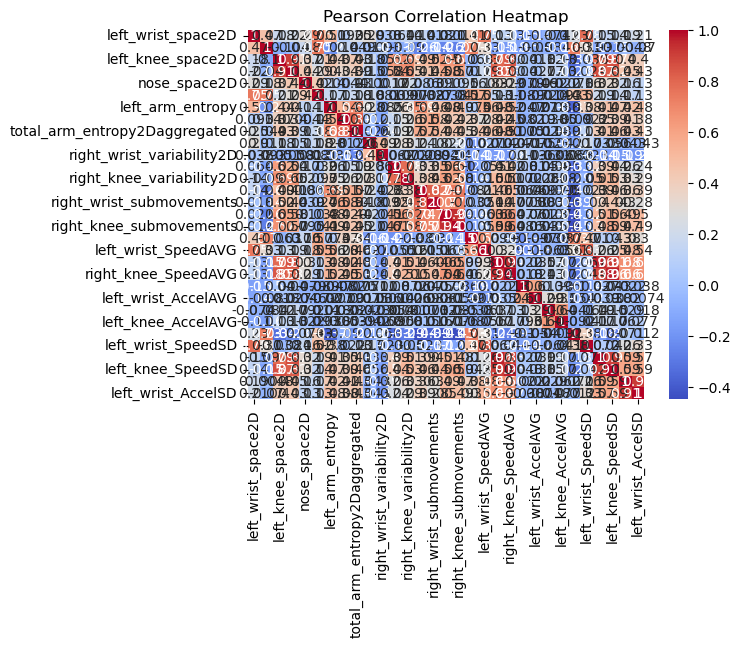

,left_wrist_space2D,right_wrist_space2D,left_knee_space2D,right_knee_space2D,nose_space2D,total_arm_boundingbox2D,left_arm_entropy,right_arm_entropy,total_arm_entropy2Daggregated,left_wrist_variability2D,...,right_wrist_AccelAVG,left_wrist_AccelAVG,right_knee_AccelAVG,left_knee_AccelAVG,right_wrist_SpeedSD,left_wrist_SpeedSD,right_knee_SpeedSD,left_knee_SpeedSD,right_wrist_AccelSD,left_wrist_AccelSD
left_wrist_space2D,1.000000,0.468816,0.182862,0.216340,0.293425,0.749590,0.512185,0.093476,0.250769,0.292805,...,-0.152200,-0.138129,-0.074054,-0.110224,0.228884,0.783688,0.146604,0.138561,0.192670,0.214368
right_wrist_space2D,0.468816,1.000000,-0.100238,-0.040249,0.182809,0.748632,-0.202842,0.141885,0.049041,0.011107,...,-0.146605,-0.080250,-0.083567,-0.155252,0.725831,0.314454,-0.097123,-0.152807,-0.004785,-0.069915
left_knee_space2D,0.182862,-0.100238,1.000000,0.907970,0.371599,0.209308,0.443088,0.368348,0.431845,0.181530,...,0.039564,0.018372,0.123345,0.131222,-0.336289,-0.037731,0.785597,0.865176,0.404808,0.404594
right_knee_space2D,0.216340,-0.040249,0.907970,1.000000,0.438909,0.293107,0.396931,0.336052,0.391129,0.147113,...,0.039661,0.026623,0.169133,0.133340,-0.229592,0.024137,0.869256,0.824402,0.454990,0.431650
nose_space2D,0.293425,0.182809,0.371599,0.438909,1.000000,0.419307,0.137751,0.004401,0.134584,0.114107,...,-0.079200,-0.045958,0.091712,0.022198,0.077896,0.164515,0.319622,0.318016,0.163596,0.133785
total_arm_boundingbox2D,0.749590,0.748632,0.209308,0.293107,0.419307,1.000000,0.165580,0.129649,0.176161,0.175013,...,-0.089097,-0.072437,-0.013976,-0.093435,0.425576,0.516006,0.185456,0.137252,0.166165,0.126877
left_arm_entropy,0.512185,-0.202842,0.443088,0.396931,0.137751,0.165580,1.000000,0.536367,0.683023,0.281098,...,-0.046953,-0.026653,0.017839,0.038133,-0.367809,0.384609,0.406510,0.472065,0.423964,0.483143
right_arm_entropy,0.093476,0.141885,0.368348,0.336052,0.004401,0.129649,0.536367,1.000000,0.810618,0.012290,...,-0.082165,0.018765,0.038048,0.049594,-0.090049,-0.021676,0.346984,0.390219,0.406754,0.380319
total_arm_entropy2Daggregated,0.250769,0.049041,0.431845,0.391129,0.134584,0.176161,0.683023,0.810618,1.000000,-0.025520,...,-0.075241,-0.001056,0.024310,0.038509,-0.220036,0.133330,0.405251,0.457169,0.428188,0.434547
left_wrist_variability2D,0.292805,0.011107,0.181530,0.147113,0.114107,0.175013,0.281098,0.012290,-0.025520,1.000000,...,0.070823,0.074703,-0.022594,-0.042338,-0.122311,0.173514,0.033117,0.055557,-0.043081,-0.042684


In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
cols_to_compare = features.columns[17:]
corr_df = features[cols_to_compare]

pearson_corr = corr_df.corr(method='pearson')
print(pearson_corr)

sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap")
plt.show()

pearson_corr

In [75]:
## code to print all of the high correlation pairs (written with the help of chatgpt)
upper = pearson_corr.where(np.triu(np.ones(pearson_corr.shape), k=1).astype(bool))

# Stack and filter
high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'correlation'})
)

high_corr_pairs = high_corr_pairs[high_corr_pairs['correlation'] > 0.7]

print(high_corr_pairs)

                         var1                           var2  correlation
4          left_wrist_space2D        total_arm_boundingbox2D     0.749590
17         left_wrist_space2D            left_wrist_SpeedAVG     0.754729
25         left_wrist_space2D             left_wrist_SpeedSD     0.783688
33        right_wrist_space2D        total_arm_boundingbox2D     0.748632
45        right_wrist_space2D           right_wrist_SpeedAVG     0.704060
53        right_wrist_space2D            right_wrist_SpeedSD     0.725831
59          left_knee_space2D             right_knee_space2D     0.907970
75          left_knee_space2D             left_knee_SpeedAVG     0.792563
76          left_knee_space2D            right_knee_SpeedAVG     0.845086
83          left_knee_space2D             right_knee_SpeedSD     0.785597
84          left_knee_space2D              left_knee_SpeedSD     0.865176
102        right_knee_space2D             left_knee_SpeedAVG     0.851597
103        right_knee_space2D         

# Normalize all the feature data for dimensionality reduction

In [76]:
normed_features = features.copy()
# remove the entropy measures that calculate each arm separately
#normed_features = normed_features.drop(['total_body_entropy2D', 'total_body_variability2D'], axis=1)
normed_features2 = normed_features.copy()
normed_features
# normalizes all the features


normed_features2[normed_features2.columns[17:]] = StandardScaler().fit_transform(normed_features[normed_features.columns[17:]])
cols_to_embed = normed_features2.columns[17:]
normed_features2 = normed_features2[cols_to_embed].dropna()

normed_features2

,left_wrist_space2D,right_wrist_space2D,left_knee_space2D,right_knee_space2D,nose_space2D,total_arm_boundingbox2D,left_arm_entropy,right_arm_entropy,total_arm_entropy2Daggregated,left_wrist_variability2D,...,right_wrist_AccelAVG,left_wrist_AccelAVG,right_knee_AccelAVG,left_knee_AccelAVG,right_wrist_SpeedSD,left_wrist_SpeedSD,right_knee_SpeedSD,left_knee_SpeedSD,right_wrist_AccelSD,left_wrist_AccelSD
0,1.833318,1.479872,-0.395224,-0.387815,1.026762,0.882586,0.215699,-0.001915,0.013436,1.257394,...,-1.040520,-0.833778,-1.749609,-0.508749,1.174808,1.485154,-0.245109,-0.109099,0.256365,0.305707
1,0.224779,0.048994,-0.799404,-0.735189,-0.430502,-0.344587,0.198753,0.204811,0.007701,-0.827793,...,-3.706720,-3.033916,-0.037719,-0.121017,0.016612,0.142342,-0.713104,-0.812034,-0.815685,-0.810109
2,0.706900,0.459364,-0.275745,-0.059908,-0.430502,0.731292,0.750944,0.535145,0.854657,-0.267351,...,0.123426,-0.029683,0.016115,0.158767,1.079046,1.416696,-0.215258,-0.184385,1.459542,2.324501
3,2.374846,-1.715525,-0.799404,-0.735189,3.850067,0.406144,0.749147,-3.315064,0.669860,-0.877177,...,-0.108936,-2.042267,-0.037719,-0.121017,-1.737905,2.065847,-0.713104,-0.812034,-0.815685,-0.810109
4,0.205963,-0.091040,0.469506,0.709103,0.558987,-0.060868,0.061106,-0.119148,-0.709428,2.654394,...,-0.005753,-0.677732,-0.077476,-0.101333,-0.354213,0.209369,0.188220,0.208842,0.173461,0.229095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,-0.371784,-0.677637,1.577625,1.113797,-0.430502,-0.174738,0.700263,0.689066,0.981716,1.843927,...,0.213704,-0.196278,0.193006,0.011921,-1.463006,-1.001299,0.350492,0.687472,-0.417766,-0.492262
433,0.451808,0.394901,-0.799404,-0.735189,-0.430502,0.566415,0.408338,0.713673,0.465522,1.139573,...,0.821321,1.121704,-0.037719,-0.121017,-0.135086,0.153219,-0.713104,-0.812034,-0.815685,-0.810109
434,1.076783,0.694635,3.146563,1.762974,1.447916,2.047903,0.579740,0.365721,0.432079,-0.049533,...,-0.557605,-0.719566,0.167033,0.047087,1.210367,1.494888,1.247144,2.228025,1.794966,1.887476
435,-0.059289,-0.300593,-0.799404,-0.735189,-0.430502,-0.154592,-0.661386,-1.732570,-2.171351,3.106532,...,0.440817,0.542833,-0.037719,-0.121017,0.627886,0.750980,-0.713104,-0.812034,-0.815685,-0.810109


# Dimensionality Reduction with UMAP

In [77]:
# call dimensionality reduction package
reducer = umap.UMAP()

# create embeddings
embedding = reducer.fit_transform(normed_features2[normed_features2.columns[17:]])
embedding.shape
embeddings = pd.DataFrame(embedding)

# add embeddings to the dataframe
features["X_embeddings"] = embeddings.iloc[:, 0]
features["Y_embeddings"] = embeddings.iloc[:, 1]
normed_features["X_embeddings"] = embeddings.iloc[:, 0]
normed_features["Y_embeddings"] = embeddings.iloc[:, 1]

Plot all gesture embeddings:

<Axes: xlabel='X_embeddings', ylabel='Y_embeddings'>

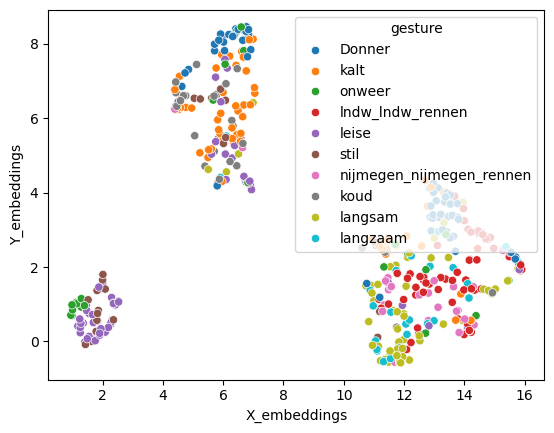

In [78]:
sns.scatterplot(data=normed_features, x="X_embeddings", y="Y_embeddings", hue="gesture")

# Set generation zero for chain 2 and chain 3


In [79]:
# set generation zero for leise chain 2
fix_row = normed_features[normed_features['fileID'] == "leise_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "leise_g_ch2_g0_compr.mp4"
fix_row["chainID"] = "ch2g0"
fix_row["chain_number"] = 2
fix_row["gesture_chain"] = 'leise_g_ch2'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for leise chain 3
fix_row = normed_features[normed_features['fileID'] == "leise_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "leise_g_ch3_g0_compr.mp4"
fix_row["chainID"] = "ch3g0"
fix_row["chain_number"] = 3
fix_row["gesture_chain"] = 'leise_g_ch3'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for langsam chain 2
fix_row = normed_features[normed_features['fileID'] == "langsam_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "langsam_g_ch2_g0_compr.mp4"
fix_row["chainID"] = "ch2g0"
fix_row["chain_number"] = 2
fix_row["gesture_chain"] = 'langsam_g_ch2'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for langsam chain 3
fix_row = normed_features[normed_features['fileID'] == "langsam_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "langsam_g_ch3_g0_compr.mp4"
fix_row["chainID"] = "ch3g0"
fix_row["chain_number"] = 3
fix_row["gesture_chain"] = 'langsam_g_ch3'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for rennen chain 2
fix_row = normed_features[normed_features['fileID'] == "lndw_lndw_rennen_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "rennen_g_ch2_g0_compr.mp4"
fix_row["chainID"] = "ch2g0"
fix_row["chain_number"] = 2
fix_row["gesture_chain"] = 'rennen_g_ch2'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for rennen chain 3
fix_row = normed_features[normed_features['fileID'] == "lndw_lndw_rennen_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "rennen_g_ch3_g0_compr.mp4"
fix_row["chainID"] = "ch3g0"
fix_row["chain_number"] = 3
fix_row["gesture_chain"] = 'rennen_g_ch3'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for Donner chain 2
fix_row = normed_features[normed_features['fileID'] == "Donner_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "Donner_g_ch2_g0_compr.mp4"
fix_row["chainID"] = "ch2g0"
fix_row["chain_number"] = 2
fix_row["gesture_chain"] = 'Donner_g_ch2'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for Donner chain 3
fix_row = normed_features[normed_features['fileID'] == "Donner_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "Donner_g_ch3_g0_compr.mp4"
fix_row["chainID"] = "ch3g0"
fix_row["chain_number"] = 3
fix_row["gesture_chain"] = 'Donner_g_ch3'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for kalt chain 2
fix_row = normed_features[normed_features['fileID'] == "kalt_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "kalt_g_ch2_g0_compr.mp4"
fix_row["chainID"] = "ch2g0"
fix_row["chain_number"] = 2
fix_row["gesture_chain"] = 'kalt_g_ch2'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for kalt chain 3
fix_row = normed_features[normed_features['fileID'] == "kalt_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "kalt_g_ch3_g0_compr.mp4"
fix_row["chainID"] = "ch3g0"
fix_row["chain_number"] = 3
fix_row["gesture_chain"] = 'kalt_g_ch3'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

five = normed_features[normed_features['fileID'] == 'kalt_g_ch3_g0_compr.mp4']

normed_features

,participantID,Age,BirthPlace,Gender,NativeLanguages,NumOfNativeLanguages,Other Languages,TotalLanguages,Extroversion,Hand,...,right_knee_AccelAVG,left_knee_AccelAVG,right_wrist_SpeedSD,left_wrist_SpeedSD,right_knee_SpeedSD,left_knee_SpeedSD,right_wrist_AccelSD,left_wrist_AccelSD,X_embeddings,Y_embeddings
0,23,35.0,Deutschland,Woman / Weiblich,Deutsch,1.0,"English (fluent), French (advanced), Italian (...",4.0,43.0,Right-handed / Rechtshänder*in,...,-1.835214e-07,-4.268481e-08,0.000275,0.000283,0.000010,0.000014,0.000013,0.000013,13.062593,3.779678
1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000e+00,0.000000e+00,0.000176,0.000163,0.000000,0.000000,0.000000,0.000000,7.049644,6.673297
2,16,27.0,Deutschland,Man / Männlich,Deutsch,1.0,English,2.0,30.0,Right-handed / Rechtshänder*in,...,5.771132e-09,3.080099e-08,0.000267,0.000277,0.000011,0.000012,0.000027,0.000038,13.466741,3.362098
3,22,32.0,"Delft, Netherlands",Man / Man,Dutch and Polish,NaN,"English (fluent), French (good knowledge), Ger...",5.0,91.0,Right-handed / Rechtshandig,...,0.000000e+00,0.000000e+00,0.000026,0.000335,0.000000,0.000000,0.000000,0.000000,6.829512,4.285472
4,30,45.0,Dresden,Woman / Weiblich,Deutsch,1.0,Englisch,2.0,51.0,Right-handed / Rechtshänder*in,...,-4.262191e-09,2.167038e-09,0.000144,0.000169,0.000019,0.000020,0.000012,0.000012,11.388920,2.348398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-8.006483e-09,2.696942e-08,0.000083,0.000096,0.000016,0.000028,0.000013,0.000021,12.389636,1.454441
443,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-2.475939e-07,-1.094193e-07,0.000274,0.000176,0.000018,0.000029,0.000026,0.000025,13.372289,3.884573
444,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-2.475939e-07,-1.094193e-07,0.000274,0.000176,0.000018,0.000029,0.000026,0.000025,13.372289,3.884573
445,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000e+00,0.000000e+00,0.000176,0.000163,0.000000,0.000000,0.000000,0.000000,7.049644,6.673297


In [80]:

# set generation zero of chain 1 for koud
fix_row = normed_features[normed_features['fileID'] == "kalt_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "koud_g_ch1_g0_compr.mp4"
fix_row["chainID"] = "ch1g0"
fix_row["chain_number"] = 1
fix_row["gesture_chain"] = 'koud_g_ch3'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero of chain 2 for koud
fix_row = normed_features[normed_features['fileID'] == "kalt_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "koud_g_ch2_g0_compr.mp4"
fix_row["chainID"] = "ch2g0"
fix_row["chain_number"] = 2
fix_row["gesture_chain"] = 'koud_g_ch2'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)


# set generation zero of chain 1 for langzaam
fix_row = normed_features[normed_features['fileID'] == "langsam_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "langzaam_g_ch1_g0_compr.mp4"
fix_row["chainID"] = "ch1g0"
fix_row["chain_number"] = 1
fix_row["gesture_chain"] = 'langzaam_g_ch1'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero of chain 2 for langzaam
fix_row = normed_features[normed_features['fileID'] == "langsam_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "langzaam_g_ch2_g0_compr.mp4"
fix_row["chainID"] = "ch2g0"
fix_row["chain_number"] = 2
fix_row["gesture_chain"] = 'langzaam_g_ch2'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)


# set generation zero of chain 1 for nijmegen_nijmegen_rennen
fix_row = normed_features[normed_features['fileID'] == "lndw_lndw_rennen_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "nijmegen_nijmegen_rennen_g_ch1_g0_compr.mp4"
fix_row["chainID"] = "ch1g0"
fix_row["chain_number"] = 1
fix_row["gesture_chain"] = 'nijmegen_nijmegen_rennen_g_ch1'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero of chain 2 for nijmegen_nijmegen_rennen
fix_row = normed_features[normed_features['fileID'] == "lndw_lndw_rennen_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "nijmegen_nijmegen_rennen_g_ch1_g0_compr.mp4"
fix_row["chainID"] = "ch2g0"
fix_row["chain_number"] = 2
fix_row["gesture_chain"] = 'nijmegen_nijmegen_rennen_g_ch2'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero of chain 1 for onweer
fix_row = normed_features[normed_features['fileID'] == "Donner_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "onweer_g_ch1_g0_compr.mp4"
fix_row["chainID"] = "ch1g0"
fix_row["chain_number"] = 1
fix_row["gesture_chain"] = 'onweer_g_ch1'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero of chain 2 for onweer
fix_row = normed_features[normed_features['fileID'] == "Donner_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "onweer_g_ch2_g0_compr.mp4"
fix_row["chainID"] = "ch2g0"
fix_row["chain_number"] = 2
fix_row["gesture_chain"] = 'onweer_g_ch2'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero of chain 1 for stil
fix_row = normed_features[normed_features['fileID'] == "leise_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "stil_g_ch1_g0_compr.mp4"
fix_row["chainID"] = "ch1g0"
fix_row["chain_number"] = 1
fix_row["gesture_chain"] = 'stil_g_ch1'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero of chain 1 for stil
fix_row = normed_features[normed_features['fileID'] == "leise_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "stil_g_ch2_g0_compr.mp4"
fix_row["chainID"] = "ch2g0"
fix_row["chain_number"] = 2
fix_row["gesture_chain"] = 'stil_g_ch2'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)



# Save Normed Features Dataframe with Embeddings


In [81]:
normed_features

,participantID,Age,BirthPlace,Gender,NativeLanguages,NumOfNativeLanguages,Other Languages,TotalLanguages,Extroversion,Hand,...,right_knee_AccelAVG,left_knee_AccelAVG,right_wrist_SpeedSD,left_wrist_SpeedSD,right_knee_SpeedSD,left_knee_SpeedSD,right_wrist_AccelSD,left_wrist_AccelSD,X_embeddings,Y_embeddings
0,23,35.0,Deutschland,Woman / Weiblich,Deutsch,1.0,"English (fluent), French (advanced), Italian (...",4.0,43.0,Right-handed / Rechtshänder*in,...,-1.835214e-07,-4.268481e-08,0.000275,0.000283,0.000010,0.000014,0.000013,0.000013,13.062593,3.779678
1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000e+00,0.000000e+00,0.000176,0.000163,0.000000,0.000000,0.000000,0.000000,7.049644,6.673297
2,16,27.0,Deutschland,Man / Männlich,Deutsch,1.0,English,2.0,30.0,Right-handed / Rechtshänder*in,...,5.771132e-09,3.080099e-08,0.000267,0.000277,0.000011,0.000012,0.000027,0.000038,13.466741,3.362098
3,22,32.0,"Delft, Netherlands",Man / Man,Dutch and Polish,NaN,"English (fluent), French (good knowledge), Ger...",5.0,91.0,Right-handed / Rechtshandig,...,0.000000e+00,0.000000e+00,0.000026,0.000335,0.000000,0.000000,0.000000,0.000000,6.829512,4.285472
4,30,45.0,Dresden,Woman / Weiblich,Deutsch,1.0,Englisch,2.0,51.0,Right-handed / Rechtshänder*in,...,-4.262191e-09,2.167038e-09,0.000144,0.000169,0.000019,0.000020,0.000012,0.000012,11.388920,2.348398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-8.006483e-09,2.696942e-08,0.000083,0.000096,0.000016,0.000028,0.000013,0.000021,12.389636,1.454441
453,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-2.475939e-07,-1.094193e-07,0.000274,0.000176,0.000018,0.000029,0.000026,0.000025,13.372289,3.884573
454,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-2.475939e-07,-1.094193e-07,0.000274,0.000176,0.000018,0.000029,0.000026,0.000025,13.372289,3.884573
455,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000e+00,0.000000e+00,0.000271,0.000036,0.000000,0.000000,0.000000,0.000000,1.556844,0.750853


In [82]:
globals()["normed_features"] = normed_features
globals()["normed_features"].to_csv(os.path.join(curfolder, f'{"normed_features_february"}.csv'), index=False)

# Euclidean Distances between Gestures

Compare one vector to others

In [83]:
# returns the euclidean distance between two normalized gesutre vectors
def calculate_distances(feature_vector1, feature_vector2):
    squared_diff =np.square(feature_vector1-feature_vector2)
    sum_squared_diff = np.sum(squared_diff)
    eucl_distance = math.sqrt(sum_squared_diff)
    return eucl_distance

# returns the distance between one gesture to every other gesture
def calculate_distances_to_all(target_segment_index, array):
    target_segment = array[target_segment_index]
    distances = np.empty(array.shape[0])
    i = 0
    for row in array:
        distances[i] = calculate_distances(target_segment, row)
        i = i+1
    return distances


In [84]:
normed_features.columns[17:48]

Index(['left_wrist_space2D', 'right_wrist_space2D', 'left_knee_space2D',
       'right_knee_space2D', 'nose_space2D', 'total_arm_boundingbox2D',
       'left_arm_entropy', 'right_arm_entropy',
       'total_arm_entropy2Daggregated', 'left_wrist_variability2D',
       'right_wrist_variability2D', 'left_knee_variability2D',
       'right_knee_variability2D', 'left_wrist_submovements',
       'right_wrist_submovements', 'left_knee_submovements',
       'right_knee_submovements', 'right_wrist_SpeedAVG',
       'left_wrist_SpeedAVG', 'left_knee_SpeedAVG', 'right_knee_SpeedAVG',
       'right_wrist_AccelAVG', 'left_wrist_AccelAVG', 'right_knee_AccelAVG',
       'left_knee_AccelAVG', 'right_wrist_SpeedSD', 'left_wrist_SpeedSD',
       'right_knee_SpeedSD', 'left_knee_SpeedSD', 'right_wrist_AccelSD',
       'left_wrist_AccelSD'],
      dtype='object')

Comparing all vectors to each other and saving in a dataframe

In [85]:
# This code was modified from code written by Šárka Kadavá

## why do we start at 32 for this?
interseg_dist = np.empty(normed_features[normed_features.columns[17:48]].shape)
interseg_dist = pd.DataFrame(interseg_dist)
interseg_dist = pd.DataFrame()

#make individual id for each segment
df_of_vectors = normed_features[normed_features.columns[17:48]].copy()
df_of_vectors = df_of_vectors.to_numpy()

# calculate distance between each segment
for i in range (normed_features[normed_features.columns[17:48]].shape[0]):
    id = normed_features.loc[i, 'fileID']
    interseg_dist_vector = calculate_distances_to_all(i, df_of_vectors)
    interseg_dist = interseg_dist.rename(index={i: id})
    interseg_dist = interseg_dist.rename(columns={i: id})
    interseg_dist[id] = interseg_dist_vector
    index = interseg_dist.index

# save to dataframe
interseg_dist.to_csv('interseg_dist_extended.csv', index=True)
interseg_dist = pd.read_csv(os.path.join(curfolder, 'interseg_dist_extended.csv')).set_index('Unnamed: 0')

interseg_dist

,Donner_g_ch2_g3_compr.mp4,kalt_g_ch1_g0_compr.mp4,Donner_g_ch1_g16_compr.mp4,onweer_g_ch2_g2_compr.mp4,kalt_g_ch2_g10_compr.mp4,lndw_lndw_rennen_g_ch1_g12_compr.mp4,leise_g_ch2_g17_compr.mp4,kalt_g_ch2_g6_compr.mp4,Donner_g_ch1_g5_compr.mp4,onweer_g_ch1_g4_compr.mp4,...,kalt_g_ch3_g0_compr.mp4,koud_g_ch1_g0_compr.mp4,koud_g_ch2_g0_compr.mp4,langzaam_g_ch1_g0_compr.mp4,langzaam_g_ch2_g0_compr.mp4,nijmegen_nijmegen_rennen_g_ch1_g0_compr.mp4,onweer_g_ch1_g0_compr.mp4,onweer_g_ch2_g0_compr.mp4,stil_g_ch1_g0_compr.mp4,stil_g_ch2_g0_compr.mp4
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,0.000000,1673.704967,1067.809510,1731.736848,979.569427,1324.999825,1662.423914,1318.409959,457.590400,1321.654685,...,1673.704967,1673.704967,1673.704967,1145.716920,1145.716920,1437.436004,1448.749802,1448.749802,1232.884217,1232.884217
kalt_g_ch1_g0_compr.mp4,1673.704967,0.000000,645.775711,63.726851,2461.478657,456.308820,2375.139794,385.086341,1459.417302,617.195510,...,0.000000,0.000000,0.000000,670.395568,670.395568,477.706946,263.134996,263.134996,858.713894,858.713894
Donner_g_ch1_g16_compr.mp4,1067.809510,645.775711,0.000000,702.727214,1884.980743,314.224456,1921.337282,395.057483,839.739639,440.417617,...,645.775711,645.775711,645.775711,266.601687,266.601687,428.226931,427.639523,427.639523,555.111839,555.111839
onweer_g_ch2_g2_compr.mp4,1731.736848,63.726851,702.727214,0.000000,2509.866804,496.353484,2433.343326,441.733672,1511.347230,675.049365,...,63.726851,63.726851,63.726851,715.481959,715.481959,505.986045,307.130197,307.130197,916.698298,916.698298
kalt_g_ch2_g10_compr.mp4,979.569427,2461.478657,1884.980743,2509.866804,0.000000,2057.802490,2397.595730,2129.493416,1076.745013,2227.041998,...,2461.478657,2461.478657,2461.478657,1875.949156,1875.949156,2156.445616,2210.317823,2210.317823,2168.315655,2168.315655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nijmegen_nijmegen_rennen_g_ch1_g0_compr.mp4,1437.436004,477.706946,428.226931,505.986045,2156.445616,198.879953,2268.523471,483.051430,1133.930867,652.423472,...,477.706946,477.706946,477.706946,425.737188,425.737188,0.000000,285.331284,285.331284,841.382602,841.382602
onweer_g_ch1_g0_compr.mp4,1448.749802,263.134996,427.639523,307.130197,2210.317823,212.365162,2281.872886,252.959058,1210.089670,570.681507,...,263.134996,263.134996,263.134996,448.037003,448.037003,285.331284,0.000000,0.000000,793.747166,793.747166
onweer_g_ch2_g0_compr.mp4,1448.749802,263.134996,427.639523,307.130197,2210.317823,212.365162,2281.872886,252.959058,1210.089670,570.681507,...,263.134996,263.134996,263.134996,448.037003,448.037003,285.331284,0.000000,0.000000,793.747166,793.747166


In [86]:
normed_features.columns



Index(['participantID', 'Age', 'BirthPlace', 'Gender', 'NativeLanguages',
       'NumOfNativeLanguages', 'Other Languages', 'TotalLanguages',
       'Extroversion', 'Hand', 'fileID', 'chainID', 'generation_number',
       'chain_number', 'gesture', 'gesture_chain', 'event',
       'left_wrist_space2D', 'right_wrist_space2D', 'left_knee_space2D',
       'right_knee_space2D', 'nose_space2D', 'total_arm_boundingbox2D',
       'left_arm_entropy', 'right_arm_entropy',
       'total_arm_entropy2Daggregated', 'left_wrist_variability2D',
       'right_wrist_variability2D', 'left_knee_variability2D',
       'right_knee_variability2D', 'left_wrist_submovements',
       'right_wrist_submovements', 'left_knee_submovements',
       'right_knee_submovements', 'right_wrist_SpeedAVG',
       'left_wrist_SpeedAVG', 'left_knee_SpeedAVG', 'right_knee_SpeedAVG',
       'right_wrist_AccelAVG', 'left_wrist_AccelAVG', 'right_knee_AccelAVG',
       'left_knee_AccelAVG', 'right_wrist_SpeedSD', 'left_wrist_Spee

# Create dataframe which compares participant gestures to previous participant gestures

In [87]:
big_df = pd.DataFrame(index=range(61), columns=['participantID', 'generation_number', 'chain_number', 'chainID', 'age', 'extrovert', 'TotalLanguages', 'Gender', 'NumOfNativeLanguages', 'diff_in_age', 'diff_in_extrovert', 'diff_in_gender', 'diff_in_TotalNativeLanguages', 'diff_in_TotalLanguages',
                               'diff_in_gesture_space_Donner', 'diff_in_entropy_Donner', 'diff_in_variability_Donner',
                               'diff_in_gesture_space_kalt', 'diff_in_entropy_kalt', 'diff_in_variability_kalt',
                                 'diff_in_gesture_space_langsam', 'diff_in_entropy_langsam','diff_in_variability_langsam',
                                   'diff_in_gesture_space_leise', 'diff_in_entropy_leise', 'diff_in_variability_leise',
                                     'diff_in_gesture_space_rennen','diff_in_entropy_rennen', 'diff_in_variability_rennen',
                                       'diff_in_gesture_space_mean', 'diff_in_entropy_mean', 'diff_in_variability_mean', 
                                       'total_dist_Donner', 'total_dist_kalt' , 'total_dist_langsam', 'total_dist_leise', 'total_dist_rennen', 'total_dist_mean'])
big_df['participantID'] = big_df.index

# rename row zero which got messed up in the interseg_dist matrix
interseg_dist = interseg_dist.rename(index={str(0): 'rennen_g_ch3_g12_compr.mp4'})
for i in range(interseg_dist.shape[0]-1):

    # get the current gesture
    curr_gesture = interseg_dist.index[i]

    # get the row of features of the current gesture and aspects of the gesture
    curr_features_row = normed_features[normed_features['fileID'] == curr_gesture]

normed_features

,participantID,Age,BirthPlace,Gender,NativeLanguages,NumOfNativeLanguages,Other Languages,TotalLanguages,Extroversion,Hand,...,right_knee_AccelAVG,left_knee_AccelAVG,right_wrist_SpeedSD,left_wrist_SpeedSD,right_knee_SpeedSD,left_knee_SpeedSD,right_wrist_AccelSD,left_wrist_AccelSD,X_embeddings,Y_embeddings
0,23,35.0,Deutschland,Woman / Weiblich,Deutsch,1.0,"English (fluent), French (advanced), Italian (...",4.0,43.0,Right-handed / Rechtshänder*in,...,-1.835214e-07,-4.268481e-08,0.000275,0.000283,0.000010,0.000014,0.000013,0.000013,13.062593,3.779678
1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000e+00,0.000000e+00,0.000176,0.000163,0.000000,0.000000,0.000000,0.000000,7.049644,6.673297
2,16,27.0,Deutschland,Man / Männlich,Deutsch,1.0,English,2.0,30.0,Right-handed / Rechtshänder*in,...,5.771132e-09,3.080099e-08,0.000267,0.000277,0.000011,0.000012,0.000027,0.000038,13.466741,3.362098
3,22,32.0,"Delft, Netherlands",Man / Man,Dutch and Polish,NaN,"English (fluent), French (good knowledge), Ger...",5.0,91.0,Right-handed / Rechtshandig,...,0.000000e+00,0.000000e+00,0.000026,0.000335,0.000000,0.000000,0.000000,0.000000,6.829512,4.285472
4,30,45.0,Dresden,Woman / Weiblich,Deutsch,1.0,Englisch,2.0,51.0,Right-handed / Rechtshänder*in,...,-4.262191e-09,2.167038e-09,0.000144,0.000169,0.000019,0.000020,0.000012,0.000012,11.388920,2.348398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-8.006483e-09,2.696942e-08,0.000083,0.000096,0.000016,0.000028,0.000013,0.000021,12.389636,1.454441
453,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-2.475939e-07,-1.094193e-07,0.000274,0.000176,0.000018,0.000029,0.000026,0.000025,13.372289,3.884573
454,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-2.475939e-07,-1.094193e-07,0.000274,0.000176,0.000018,0.000029,0.000026,0.000025,13.372289,3.884573
455,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000e+00,0.000000e+00,0.000271,0.000036,0.000000,0.000000,0.000000,0.000000,1.556844,0.750853


In [88]:
interseg_dist = pd.read_csv(os.path.join(curfolder, 'interseg_dist_extended.csv')).set_index('Unnamed: 0')
nijmegen_gestures  = ['koud', 'langzaam', 'nijmegen_nijmegen_rennen', 'onweer', 'stil']
translation_dictionary = {"koud": "kalt", "langzaam": "langsam", "nijmegen_nijmegen_rennen": "rennen", "onweer": "Donner", "stil": "leise"}
big_df = pd.DataFrame(index=range(130), columns=['participantID', 'generation_number', 'chain_number', 'chainID', 'event','age', 'extrovert', 'TotalLanguages', 'Gender', 'NumOfNativeLanguages', 'diff_in_age', 'diff_in_extrovert', 'diff_in_gender', 'diff_in_TotalNativeLanguages', 'diff_in_TotalLanguages',
                               ])
big_df['participantID'] = big_df.index

interseg_dist = interseg_dist.rename(index={str(0): 'rennen_g_ch3_g12_compr.mp4'})
#normed_features = normed_features.drop(437)
interseg_dist = interseg_dist.loc[interseg_dist.index.notna()]


for i in range(1, interseg_dist.shape[0]-2):
    print(i)

    # get the current gesture
    curr_gesture = interseg_dist.index[i]

    # get the row of features of the current gesture and aspects of the gesture
    curr_features_row = normed_features[normed_features['fileID'] == curr_gesture]
    gesture = curr_features_row["gesture"].iloc[0]
    generation_number = curr_features_row["generation_number"].iloc[0]
    generation_number = generation_number.astype(int)

    # if the current gesture is seed zero, go to the next iteration
    if generation_number == 0:
        continue
    chain_number = curr_features_row["chain_number"].iloc[0]
    chain_number =chain_number.astype(int)
    chainID = curr_features_row["chainID"].iloc[0]
    participantID_curr = curr_features_row["participantID"].iloc[0]
    #get the event
    event = curr_features_row["event"].iloc[0]
    ## if 
    # get the previous gesture
    previous_gesture = gesture + "_g_ch" + str(chain_number) + "_g" + str((generation_number)-1) + "_compr.mp4"
    print(gesture)
    print(previous_gesture)
    ### GET THE ENDING FOR THE EVENT IN THE PREVIOUS GESTURE
    if curr_gesture == "rennen_g_ch1_g17_compr.mp4" or curr_gesture == "langsam_g_ch2_g8_compr.mp4" or curr_gesture == "langsam_g_ch2_g19_compr.mp4" or previous_gesture== "rennen_g_ch1_g17_compr.mp4" or previous_gesture == "langsam_g_ch2_g8_compr.mp4" or previous_gesture== "langsam_g_ch2_g19_compr.mp4" or previous_gesture == 'koud_g_ch2_g0_compr.mp4' or previous_gesture == "onweer_g_ch2_g0_compr.mp4" or previous_gesture == 'Donner_g_ch2_g3_compr.mp4' or previous_gesture == 'nijmegen_nijmegen_rennen_g_ch1_g0_compr.mp4' or previous_gesture == 'stil_g_ch1_g0_compr.mp4' or previous_gesture == "langzaam_g_ch1_g0_compr.mp4" or previous_gesture == "kalt_g_ch2_g7_compr.mp4" or previous_gesture == "langzaam_g_ch2_g0_compr.mp4" or previous_gesture == "stil_g_ch2_g0_compr.mp4" or previous_gesture == "nijmegen_nijmegen_rennen_g_ch2_g0_compr.mp4" or previous_gesture == "lndw_lndw_rennen_g_ch2_g0_compr.mp4" or previous_gesture == "onweer_g_ch1_g0_compr.mp4" or previous_gesture == "koud_g_ch1_g0_compr.mp4" or previous_gesture == "lndw_lndw_rennen_g_ch3_g0_compr.mp4":
        continue
    
    # get the previous gesture in the correct event (nijmegen or lndw)
    prev_features_row = normed_features[
    (normed_features['fileID'] == previous_gesture) &
    (normed_features['event'] == event)]

    if event == 'nijmegen':
        participantID_curr = (participantID_curr)+60
        gesture = translation_dictionary[gesture]
    if event == 'lndw':
        if gesture == 'lndw_lndw_rennen':
            gesture = 'rennen'
    big_df.loc[participantID_curr, 'generation_number'] = generation_number
    big_df.loc[participantID_curr, 'chain_number'] = chain_number
    big_df.loc[participantID_curr, 'chainID'] = chainID
    big_df.loc[participantID_curr, 'event'] = event
    

    distance = interseg_dist.loc[previous_gesture, curr_gesture]
    big_df.loc[participantID_curr, 'total_dist_' + gesture] =distance
    participant_ages = big_df.loc[big_df['participantID'] == participantID_curr, 'age']

    if not participant_ages.empty and pd.isna(participant_ages.iloc[0]):
        #get the distance between the ages
        previous_age = prev_features_row["Age"].iloc[0]
        curr_age = curr_features_row["Age"].iloc[0]
        big_df.loc[participantID_curr, 'age'] = curr_age
        # if we don't know the ages, skip this iteration
        if math.isnan(previous_age) or math.isnan(curr_age):
            continue
    #get the difference in ages
        diff_in_age = int(abs(curr_age - previous_age))
        big_df.loc[participantID_curr, 'diff_in_age'] = diff_in_age

    participant_ext = big_df.loc[big_df['participantID'] == participantID_curr, 'extrovert']

    if not participant_ext.empty and pd.isna(participant_ext.iloc[0]):
    #get the difference in extroversion
    #if pd.isna(big_df.loc[big_df['participantID'] == participantID_curr, 'extrovert'].iloc[0]):
        previous_extrovert = prev_features_row["Extroversion"].iloc[0]
        curr_extrovert = curr_features_row["Extroversion"].iloc[0]
        big_df.loc[participantID_curr, 'extrovert'] = curr_extrovert
        # if we don't know the extroversion, skip this iteration
        if math.isnan(previous_extrovert) or math.isnan(curr_extrovert):
            continue
        #get the difference in extroversion
        diff_in_extrovert = int(abs(curr_extrovert - previous_extrovert))
        big_df.loc[participantID_curr, 'diff_in_extrovert'] = diff_in_extrovert

    participant_lang = big_df.loc[big_df['participantID'] == participantID_curr, 'TotalLanguages']

    if not participant_lang.empty and pd.isna(participant_lang.iloc[0]):
    #if pd.isna(big_df.loc[big_df['participantID'] == participantID_curr, 'TotalLanguages'].iloc[0]):
        #get the distance between the ages
        previous_langs = prev_features_row["TotalLanguages"].iloc[0]
        curr_langs = curr_features_row["TotalLanguages"].iloc[0]
        big_df.loc[participantID_curr, 'TotalLanguages'] = curr_langs
        # if we don't know the ages, skip this iteration
        if math.isnan(previous_langs) or math.isnan(curr_langs):
            continue
    #get the difference in ages
        diff_in_TotalLanguages = int(abs(curr_langs - previous_langs))
        big_df.loc[participantID_curr, 'diff_in_TotalLanguages'] = diff_in_TotalLanguages

    #if pd.isna(big_df.loc[big_df['participantID'] == participantID_curr, 'NumOfNativeLanguages'].iloc[0]):
    participant_numlang = big_df.loc[big_df['participantID'] == participantID_curr, 'NumOfNativeLanguages']

    if not participant_numlang.empty and pd.isna(participant_numlang.iloc[0]):
        #get the distance between the ages
        previous_Nlangs = prev_features_row["NumOfNativeLanguages"].iloc[0]
        curr_Nlangs = curr_features_row["NumOfNativeLanguages"].iloc[0]
        big_df.loc[participantID_curr, 'NumOfNativeLanguages'] = curr_Nlangs
        # if we don't know the ages, skip this iteration
        if math.isnan(previous_Nlangs) or math.isnan(curr_Nlangs):
            continue
    #get the difference in native languages
        diff_in_TotalNativeLanguages = int(abs(curr_Nlangs - previous_Nlangs))
        big_df.loc[participantID_curr, 'diff_in_TotalNativeLanguages'] = diff_in_TotalNativeLanguages

    #if pd.isna(big_df.loc[big_df['participantID'] == participantID_curr, 'Gender'].iloc[0]):
    participant_gender = big_df.loc[big_df['participantID'] == participantID_curr, 'Gender']

    if not participant_gender.empty and pd.isna(participant_gender.iloc[0]):
        #get the distance between the ages
        previous_gender = prev_features_row["Gender"].iloc[0]
        curr_gender = curr_features_row["Gender"].iloc[0]
        big_df.loc[participantID_curr, 'Gender'] = curr_gender
        # if we don't know the ages, skip this iteration
        if math.isnan(previous_Nlangs) or math.isnan(curr_Nlangs):
            continue
    #get the difference in gender (0 means no difference, 1 means difference)
        diff_in_Gender = int(previous_gender != curr_gender)
        big_df.loc[participantID_curr, 'diff_in_gender'] = diff_in_Gender

"""
    # get the difference between gesture spaces and the current gesture space
    gesture_space_diff = abs(curr_features_row["total_gesture_space2D"].iloc[0] - prev_features_row["total_gesture_space2D"].iloc[0])
    big_df.loc[participantID_curr, 'diff_in_gesture_space_' + gesture] =gesture_space_diff
    big_df.loc[participantID_curr, 'gesture_space_' + gesture] = curr_features_row["total_gesture_space2D"].iloc[0]
     # get the difference between entrophies and the current entropy
    entropy_diff = abs(curr_features_row["total_body_entropy2Daggregated"].iloc[0] - prev_features_row["total_body_entropy2Daggregated"].iloc[0])
    big_df.loc[participantID_curr, 'diff_in_entropy_' + gesture] = entropy_diff
    big_df.loc[participantID_curr, 'entropy_' + gesture] = curr_features_row["total_body_entropy2Daggregated"].iloc[0]
    # # get the difference between variabilities and the current variabilities
    variability_diff = abs(curr_features_row["total_body_variability2Daggregated"].iloc[0] - prev_features_row["total_body_variability2Daggregated"].iloc[0])
    big_df.loc[participantID_curr, 'diff_in_variability_' + gesture] = variability_diff
    big_df.loc[participantID_curr, 'variability_' + gesture] = curr_features_row["total_body_variability2Daggregated"].iloc[0]     
    ## get the difference betweeen bounding boxes and the current bounding boxes
    bounding_box_diff = abs(curr_features_row["total_arm_boundingbox2D"].iloc[0] - prev_features_row["total_arm_boundingbox2D"].iloc[0])
    big_df.loc[participantID_curr, 'diff_in_arm_bounding_box_' + gesture] = bounding_box_diff
    big_df.loc[participantID_curr, 'arm_bounding_box_' + gesture] = curr_features_row["total_arm_boundingbox2D"].iloc[0]

    ## get the difference between intermittency and the current intermittency
    intermittency_diff = abs(curr_features_row["total_body_intermittency"].iloc[0] - prev_features_row["total_body_intermittency"].iloc[0])
    big_df.loc[participantID_curr, 'diff_in_intermittency_' + gesture] = intermittency_diff
    big_df.loc[participantID_curr, 'total_body_intermittency_' + gesture] = curr_features_row["total_body_intermittency"].iloc[0]

    ## get the difference between time and the current time
    time_diff = abs(curr_features_row["total_time"].iloc[0] - prev_features_row["total_time"].iloc[0])
    big_df.loc[participantID_curr, 'diff_in_time_' + gesture] = time_diff
    big_df.loc[participantID_curr, 'time_' + gesture] = curr_features_row["total_time"].iloc[0]
"""
    
big_df

# Saving to Csv File
globals()["big_df"] = big_df
globals()["big_df"].to_csv(os.path.join(curfolder, f'{"gesture_to_prev_gesture_extended_february"}.csv'), index=False)

interseg_dist
curr_gesture
big_df

1
2
Donner
Donner_g_ch1_g15_compr.mp4
3
onweer
onweer_g_ch2_g1_compr.mp4
4
kalt
kalt_g_ch2_g9_compr.mp4
5
lndw_lndw_rennen
lndw_lndw_rennen_g_ch1_g11_compr.mp4
6
leise
leise_g_ch2_g16_compr.mp4
7
kalt
kalt_g_ch2_g5_compr.mp4
8
Donner
Donner_g_ch1_g4_compr.mp4
9
onweer
onweer_g_ch1_g3_compr.mp4
10
lndw_lndw_rennen
lndw_lndw_rennen_g_ch1_g15_compr.mp4
11
kalt
kalt_g_ch2_g13_compr.mp4
12
stil
stil_g_ch1_g7_compr.mp4
13
nijmegen_nijmegen_rennen
nijmegen_nijmegen_rennen_g_ch1_g7_compr.mp4
14
onweer
onweer_g_ch2_g5_compr.mp4
15
Donner
Donner_g_ch1_g11_compr.mp4
16
kalt
kalt_g_ch1_g3_compr.mp4
17
Donner
Donner_g_ch2_g6_compr.mp4
18
Donner
Donner_g_ch1_g0_compr.mp4
19
kalt
kalt_g_ch2_g1_compr.mp4
20
leise
leise_g_ch2_g12_compr.mp4
21
Donner
Donner_g_ch2_g17_compr.mp4
22
koud
koud_g_ch1_g3_compr.mp4
23
langsam
langsam_g_ch3_g17_compr.mp4
24
leise
leise_g_ch1_g19_compr.mp4
25
kalt
kalt_g_ch3_g12_compr.mp4
26
lndw_lndw_rennen
lndw_lndw_rennen_g_ch3_g3_compr.mp4
27
leise
leise_g_ch3_g4_compr.mp4
2

,participantID,generation_number,chain_number,chainID,event,age,extrovert,TotalLanguages,Gender,NumOfNativeLanguages,diff_in_age,diff_in_extrovert,diff_in_gender,diff_in_TotalNativeLanguages,diff_in_TotalLanguages,total_dist_Donner,total_dist_kalt,total_dist_rennen,total_dist_leise,total_dist_langsam
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,1,ch1g1,lndw,26.0,40.0,3.0,Woman / Weiblich,1.0,NaN,NaN,NaN,NaN,NaN,371.589446,63.482606,113.892385,916.667475,510.707321
2,2,2,1,ch1g2,lndw,24.0,17.0,7.0,Prefer not to say / Keine Angabe,1.0,2,23,1,0,4,351.309343,1320.565574,344.068473,891.667642,492.255137
3,3,3,1,ch1g3,lndw,32.0,60.0,3.0,Woman / Weiblich,1.0,8,43,1,0,4,856.393344,1222.207590,104.143568,347.210622,468.059928
4,4,4,1,ch1g4,lndw,60.0,86.0,3.0,Woman / Weiblich,1.0,28,26,0,0,0,241.742901,364.375359,153.562168,1065.788240,459.300411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
126,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127,127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128,128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
big_df.columns

Index(['participantID', 'generation_number', 'chain_number', 'chainID',
       'event', 'age', 'extrovert', 'TotalLanguages', 'Gender',
       'NumOfNativeLanguages', 'diff_in_age', 'diff_in_extrovert',
       'diff_in_gender', 'diff_in_TotalNativeLanguages',
       'diff_in_TotalLanguages', 'total_dist_Donner', 'total_dist_kalt',
       'total_dist_rennen', 'total_dist_leise', 'total_dist_langsam'],
      dtype='object')

In [90]:
big_df = pd.read_csv('/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/StatisticsFolder/gesture_to_prev_gesture_extended.csv')

In [91]:
normed_features = pd.read_csv('/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/StatisticsFolder/normed_features.csv')

In [92]:
# create a final dataframe with everything that needed to perform statistics including feature data and comparison data
final_dataframe = normed_features[['participantID', 'Age', 'Gender', 'NumOfNativeLanguages', 'TotalLanguages', 'event', 'Extroversion', 'fileID', 'chainID', 'generation_number', 'chain_number', 'gesture', 'gesture_chain', 'left_wrist_space2D', 'right_wrist_space2D', 'left_knee_space2D',
       'right_knee_space2D', 'nose_space2D', 'total_arm_boundingbox2D',
       'total_lower_body_boundingbox2D', 'left_arm_entropy',
       'right_arm_entropy', 'left_wrist_entropy',
       'total_arm_entropy2Daggregated', 'left_wrist_variability2D',
       'right_wrist_variability2D', 'left_knee_variability2D',
       'right_knee_variability2D', 'left_wrist_submovements',
       'right_wrist_submovements', 'left_knee_submovements',
       'right_wrist_SpeedAVG', 'left_wrist_SpeedAVG', 'left_knee_SpeedAVG',
       'right_knee_SpeedAVG', 'right_wrist_AccelAVG', 'left_wrist_AccelAVG',
       'right_knee_AccelAVG', 'left_knee_AccelAVG', 'right_wrist_SpeedSD',
       'left_wrist_SpeedSD', 'right_knee_SpeedSD', 'left_knee_SpeedSD',
       'right_wrist_AccelSD', 'left_wrist_AccelSD', 'right_wrist_SpeedRange',
       'left_wrist_SpeedRange', 'right_knee_SpeedRange',
       'left_knee_SpeedRange', 'right_wrist_AccelRange',
       'left_wrist_AccelRange', 'right_knee_AccelRange',
       'left_knee_AccelRange', 'right_wrist_SpeedIntegral',
       'left_wrist_SpeedIntegral', 'right_knee_SpeedIntegral',
       'left_knee_SpeedIntegral',  'X_embeddings', 'Y_embeddings']].copy()
translation_dictionary = {"koud": "kalt", "langzaam": "langsam", "nijmegen_nijmegen_rennen": "rennen", "onweer": "Donner", "stil": "leise"}

for index, row in final_dataframe.iterrows():
    # get the relevent information for the current gesture
    participantID = row['participantID']
    gesture = row['gesture']
    event = row["event"]
    if event == 'nijmegen':
        participantID_curr = (participantID_curr)+60
        gesture = translation_dictionary[gesture]
    if event == 'lndw':
        if gesture == 'lndw_lndw_rennen':
            gesture = 'rennen'
    
    
    final_dataframe.loc[index, "generation_number"] = (final_dataframe.loc[index, "generation_number"]) + 1
    curr_row = big_df[big_df["participantID"] == participantID]
    # find the total distance between this gesture and the previous gesture
    final_dataframe.loc[index, 'total_distance'] = curr_row['total_dist_' + gesture].iloc[0]

    ## add in all of the original features
    

    """
    # find the diff_in_gesture_space between this gesture and the previous gesture
    final_dataframe.loc[index, 'diff_in_gesture_space'] = curr_row['diff_in_gesture_space_' + gesture].iloc[0]
    # find the diff_in_entropy between this gesture and the previous gesture 
    final_dataframe.loc[index, 'diff_in_entropy'] = curr_row['diff_in_entropy_' + gesture].iloc[0]
    # find the diff_in_variability between this gesture and the previous gesture 
    final_dataframe.loc[index, 'diff_in_variability'] = curr_row['diff_in_variability_' + gesture].iloc[0]
    # find the diff_in_boundingbox between this gesture and the previous gesture 
    final_dataframe.loc[index, 'diff_in_arm_bounding_box'] = curr_row['diff_in_arm_bounding_box_' + gesture].iloc[0]
    # find the diff_in_intermittency between this gesture and the previous gesture 
    final_dataframe.loc[index, 'diff_in_intermittency'] = curr_row['diff_in_intermittency_' + gesture].iloc[0]
    # find the diff_in_time between this gesture and the previous gesture 
    final_dataframe.loc[index, 'diff_in_time'] = curr_row['diff_in_time_' + gesture].iloc[0]
    """
    # find the difference in age an extroversion between this participant and the previous
    final_dataframe.loc[index, 'diff_in_age'] = curr_row['diff_in_age'].iloc[0]
    final_dataframe.loc[index, 'diff_in_extrovet'] = curr_row['diff_in_extrovert'].iloc[0]
    final_dataframe.loc[index, 'diff_in_gender'] = curr_row['diff_in_gender'].iloc[0]
    final_dataframe.loc[index, 'diff_in_TotalLanguages'] = curr_row['diff_in_TotalLanguages'].iloc[0]
    final_dataframe.loc[index, 'diff_in_TotalNativeLanguages'] = curr_row['diff_in_TotalNativeLanguages'].iloc[0]

    # get the categorical age
    Age = curr_row["age"].iloc[0]
    age_category = ""
    if Age < 12:
        age_category = "Gen_Alpha"
    if Age >= 12 and Age <28:
        age_category = "Gen_Z"
    if Age >= 28 and Age <45:
        age_category = "Millenial"
    if Age >= 45 and Age <60:
        age_category = "GenX"
    if Age >= 60 and Age <78:
        age_category = "Baby_Boomer"
    if Age >=78:
        age_category = "Silent_Gen"

    final_dataframe.loc[index, 'Age_category'] = age_category

    #get the categorical extroversion
    extrovert = curr_row["extrovert"].iloc[0]
    extrovert_category = ""
    if extrovert < 50:
        extrovert_category = "Introvert"
    if Age >= 50:
        extrovert_category = "Extrovert"

    final_dataframe.loc[index, 'Extrovert_category'] = extrovert_category

# save to a dataframe
globals()["final_dataframe"] = final_dataframe

globals()["final_dataframe"].to_csv(os.path.join(curfolder, f'{"final_stats_dataframe_extended_february"}.csv'), index=False)
final_dataframe

,participantID,Age,Gender,NumOfNativeLanguages,TotalLanguages,event,Extroversion,fileID,chainID,generation_number,...,X_embeddings,Y_embeddings,total_distance,diff_in_age,diff_in_extrovet,diff_in_gender,diff_in_TotalLanguages,diff_in_TotalNativeLanguages,Age_category,Extrovert_category
0,23,35.0,Woman / Weiblich,1.0,4.0,lndw,43.0,Donner_g_ch2_g3_compr.mp4,ch2g3,4.0,...,9.953186,16.553760,NaN,24.0,26.0,0.0,1.0,0.0,Millenial,Introvert
1,0,NaN,NaN,NaN,NaN,lndw,NaN,kalt_g_ch1_g0_compr.mp4,ch1g0,1.0,...,-3.047547,8.861458,NaN,NaN,NaN,NaN,NaN,NaN,,
2,16,27.0,Man / Männlich,1.0,2.0,lndw,30.0,Donner_g_ch1_g16_compr.mp4,ch1g16,17.0,...,10.690100,15.937997,NaN,17.0,40.0,1.0,3.0,0.0,Gen_Z,Introvert
3,22,32.0,Man / Man,NaN,5.0,nijmegen,91.0,onweer_g_ch2_g2_compr.mp4,ch2g2,3.0,...,-3.587382,10.205219,NaN,37.0,19.0,1.0,0.0,0.0,GenX,Extrovert
4,30,45.0,Woman / Weiblich,1.0,2.0,lndw,51.0,kalt_g_ch2_g10_compr.mp4,ch2g10,11.0,...,6.838797,14.397810,NaN,24.0,6.0,0.0,2.0,0.0,GenX,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,0,NaN,NaN,NaN,NaN,lndw,NaN,langsam_g_ch3_g0_compr.mp4,ch3g0,1.0,...,9.217481,14.313458,NaN,NaN,NaN,NaN,NaN,NaN,,
441,0,NaN,NaN,NaN,NaN,lndw,NaN,Donner_g_ch2_g0_compr.mp4,ch2g0,1.0,...,9.867407,16.319271,NaN,NaN,NaN,NaN,NaN,NaN,,
442,0,NaN,NaN,NaN,NaN,lndw,NaN,Donner_g_ch3_g0_compr.mp4,ch3g0,1.0,...,9.867407,16.319271,NaN,NaN,NaN,NaN,NaN,NaN,,
443,0,NaN,NaN,NaN,NaN,lndw,NaN,kalt_g_ch2_g0_compr.mp4,ch2g0,1.0,...,-3.047547,8.861458,NaN,NaN,NaN,NaN,NaN,NaN,,


In [93]:
final_dataframe

,participantID,Age,Gender,NumOfNativeLanguages,TotalLanguages,event,Extroversion,fileID,chainID,generation_number,...,X_embeddings,Y_embeddings,total_distance,diff_in_age,diff_in_extrovet,diff_in_gender,diff_in_TotalLanguages,diff_in_TotalNativeLanguages,Age_category,Extrovert_category
0,23,35.0,Woman / Weiblich,1.0,4.0,lndw,43.0,Donner_g_ch2_g3_compr.mp4,ch2g3,4.0,...,9.953186,16.553760,NaN,24.0,26.0,0.0,1.0,0.0,Millenial,Introvert
1,0,NaN,NaN,NaN,NaN,lndw,NaN,kalt_g_ch1_g0_compr.mp4,ch1g0,1.0,...,-3.047547,8.861458,NaN,NaN,NaN,NaN,NaN,NaN,,
2,16,27.0,Man / Männlich,1.0,2.0,lndw,30.0,Donner_g_ch1_g16_compr.mp4,ch1g16,17.0,...,10.690100,15.937997,NaN,17.0,40.0,1.0,3.0,0.0,Gen_Z,Introvert
3,22,32.0,Man / Man,NaN,5.0,nijmegen,91.0,onweer_g_ch2_g2_compr.mp4,ch2g2,3.0,...,-3.587382,10.205219,NaN,37.0,19.0,1.0,0.0,0.0,GenX,Extrovert
4,30,45.0,Woman / Weiblich,1.0,2.0,lndw,51.0,kalt_g_ch2_g10_compr.mp4,ch2g10,11.0,...,6.838797,14.397810,NaN,24.0,6.0,0.0,2.0,0.0,GenX,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,0,NaN,NaN,NaN,NaN,lndw,NaN,langsam_g_ch3_g0_compr.mp4,ch3g0,1.0,...,9.217481,14.313458,NaN,NaN,NaN,NaN,NaN,NaN,,
441,0,NaN,NaN,NaN,NaN,lndw,NaN,Donner_g_ch2_g0_compr.mp4,ch2g0,1.0,...,9.867407,16.319271,NaN,NaN,NaN,NaN,NaN,NaN,,
442,0,NaN,NaN,NaN,NaN,lndw,NaN,Donner_g_ch3_g0_compr.mp4,ch3g0,1.0,...,9.867407,16.319271,NaN,NaN,NaN,NaN,NaN,NaN,,
443,0,NaN,NaN,NaN,NaN,lndw,NaN,kalt_g_ch2_g0_compr.mp4,ch2g0,1.0,...,-3.047547,8.861458,NaN,NaN,NaN,NaN,NaN,NaN,,
